# Procesado de datos

In [ ]:
import numpy as np

data_dir = './Data/DataAug.csv' #Directorio y fichero en donde se encuentran los datos obtenidos con el Data Augmentation

pageSize = 50       #Número de filas en un ejemplo
maxPages = 200000   #Número de ejemplos guardados

f = open(data_dir)  #Abrir el fichero y leer todos los datos

data = f.read()
f.close()
lines = data.split('\n')
header = lines[0].split(',')
lines = lines[0:]

float_data = np.zeros((len(lines)-1, len(header)))
final_data = np.zeros((maxPages, pageSize, len(header)))  #La estructura donde se guardan los datos es en un tensor de dimensión 
                                                          # 200000 X 50 X 8

for i, line in enumerate(lines):
  if(len(line) > 0):
    values = [float(x) for x in line.split(',')]
    float_data[i, :] = values

page = 0
while (page < maxPages):
  i = 0
  while (i < pageSize):
    values = [(x) for x in lines[page * pageSize + i].split(',')]
    final_data[page, i, :] = values
    i += 1
  page += 1 

mean = float_data.mean(axis=0)  #Se normalizan los datos restándole la media y dividiéndolos por la varianza
float_data -= mean
std = float_data.std(axis=0)
vari = float_data.var(axis=0)
float_data /= vari

final_data -= mean
final_data /= vari


final_data[0]

array([[-1.88979466e-02, -1.08859302e-02,  2.42951403e-01, ...,
         8.92038826e-03, -6.17721007e-04,  6.52066080e-03],
       [-7.05139026e-02,  2.29504780e-01,  1.87353490e-01, ...,
        -1.20434767e-02, -1.29710231e-02,  3.16400377e-03],
       [-9.35234252e-02,  4.75874858e-02,  1.06095001e-01, ...,
        -9.38608541e-03, -1.38598804e-02, -1.39005724e-03],
       ...,
       [ 6.44025055e-01,  3.07469335e-01, -5.21519903e-01, ...,
        -5.99052981e-03,  2.91680676e-02, -7.48537353e-02],
       [ 6.72631489e-01,  4.24416167e-01, -5.91017294e-01, ...,
         5.23244468e-02,  4.08052458e-03, -7.06235623e-02],
       [ 7.95763529e-01,  4.11422074e-01, -4.75544705e-01, ...,
         5.05315689e-04,  2.15855709e-02, -6.88274563e-02]])

In [15]:
print(final_data.shape)
print(float_data.shape)

(200000, 50, 8)
(10000000, 8)


In [2]:
array_labels = './Data/LabelsDataAug.csv'    #Directorio y fichero que contiene las etiquetas de los ejemplos anteriores

f = open(array_labels)    #Abrir el fichero y leer todos los datos

data = f.read()
f.close()
lines = data.split('\n')
header = lines[0].split(',')
lines = lines[0:]

array_data = np.zeros((len(lines), len(header)))

for i, line in enumerate(lines):
    if(len(line) > 0):
        values = [float(x) for x in line.split(',')]
        array_data[i, :] = values
array_data[0]

array([4., 2., 6., ..., 4., 2., 6.])

# Generación del modelo

In [11]:
x_train = final_data[:160000]           #Se divide el conjunto de datos en 2: Entrenamiento y validación
y_train = array_data[0][:160000]        #En total se tienen 200000 ejemplos, de los cuales 160000 son de entrenamiento
                                        #40000 son de validación
x_test = final_data[160000:160000+40000]
y_test = array_data[0][160000:160000+40000]

print(final_data.shape)

(200000, 50, 8)


# Entrenamiento del modelo

In [6]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
import numpy as np

model = keras.Sequential()  #Se defini el modelo neuronal LSTM y sus hiperparámetros
model.add(keras.layers.LSTM(64, input_shape = (x_train.shape[1:]), activation='relu', return_sequences=True))
model.add(keras.layers.LSTM(32, activation='relu'))
model.add(keras.layers.Dense(32, activation='relu'))
model.add(keras.layers.Dense(7, activation='softmax'))

opt = keras.optimizers.Adam(learning_rate=5e-3, decay=1e-5)

#La función de pérdida es la sparse_categorical_crossentropy debido a que se trata de un problema de clasificación y
#porque las etiquetas no están codificadas con el método One-Hot, sino que se tratan
#de números enteros
model.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

#Se entrena el modelo
history = model.fit(x_train, y_train, epochs=4, validation_data=(x_test, y_test))

Epoch 1/4
5000/5000 [==============================] - 87s 17ms/step - loss: 7.1280 - accuracy: 0.8995 - val_loss: 6.9168e-04 - val_accuracy: 1.0000
Epoch 2/4
5000/5000 [==============================] - 86s 17ms/step - loss: 2.8738 - accuracy: 0.9843 - val_loss: 0.2464 - val_accuracy: 0.8688
Epoch 3/4
5000/5000 [==============================] - 87s 17ms/step - loss: 9630.6621 - accuracy: 0.4288 - val_loss: 1.9465 - val_accuracy: 0.1425
Epoch 4/4
5000/5000 [==============================] - 86s 17ms/step - loss: 1.9464 - accuracy: 0.1421 - val_loss: 1.9464 - val_accuracy: 0.1440


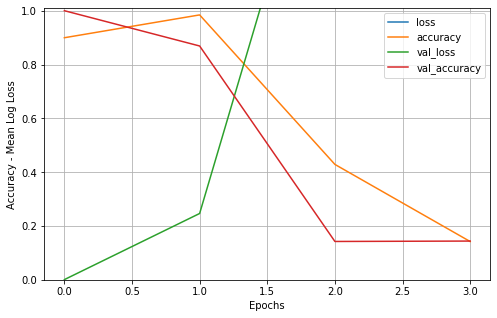

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
results=pd.DataFrame(history.history)
results.plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel ("Epochs")
plt.ylabel ("Accuracy - Mean Log Loss")
plt.gca().set_ylim(0, 1.01) 
plt.show()  #Visualizar el rendimiento del modelo

# Validación del modelo

In [40]:
Ftest_dir = './DataArduino.csv'  #Leer los datos obtenidos manualmente con el Arduino, se cargan en un tensor de dimensión 280 X 50 X 8
                              #Se normalizan los datos
pageSize = 50
maxPages = 280

f = open(Ftest_dir)

data = f.read()
f.close()
lines = data.split('\n')
header = lines[0].split(',')
lines = lines[0:]

float_data = np.zeros((len(lines)-1, len(header)))
final_data = np.zeros((maxPages, pageSize, len(header)))

for i, line in enumerate(lines):
  if(len(line) > 0):
    values = [float(x) for x in line.split(',')]
    float_data[i, :] = values

page = 0
while (page < maxPages):
  i = 0
  while (i < pageSize):
    values = [(x) for x in lines[page * pageSize + i].split(',')]
    final_data[page, i, :] = values
    i += 1
  page += 1 

mean = float_data.mean(axis=0)
float_data -= mean

vari = float_data.var(axis=0)
float_data /= vari

final_data -= mean
final_data /= vari

In [41]:
mean

array([-0.61536286,  0.78203286,  7.97892714,  0.05060429,  2.18662   ,
        1.35041643,  8.82454429,  5.37788214])

In [42]:
vari

array([  16.19709967,    1.58783037,    9.19509096,   68.63964153,
        929.41690028,   62.71353118,  540.15476605, 1023.22386156])

In [43]:
Farray_labels = './LabelsArduino.csv'      #Leer las etiquetas de los datos obtenidos manualmente

f = open(Farray_labels)

data = f.read()
f.close()
lines = data.split('\n')
header = lines[0].split(',')
lines = lines[0:]

Farray_data = np.zeros((len(lines), len(header)))

for i, line in enumerate(lines):
    if(len(line) > 0):
        values = [float(x) for x in line.split(',')]
        Farray_data[i, :] = values
Farray_data[0].shape

(280,)

In [44]:
x_Ftest = final_data        #Preparar los ejemplos y las etiquetas
y_Ftest = Farray_data[0]

print ("x_test:",x_Ftest.shape)
print ("t_test:",y_Ftest.shape)

x_test: (280, 50, 8)
t_test: (280,)


In [45]:
model.evaluate(x_Ftest, y_Ftest)    #Evaluar el modelo

9/9 [==============================] - 0s 7ms/step - loss: 2.9256e-06 - accuracy: 1.0000


[2.925602302639163e-06, 1.0]

In [46]:
model_json = model.to_json()            #Guardar el modelo LSTM y sus pesos
with open("modelDeepLSTM.json", "w") as json_file:
    json_file.write(model_json)
model.save_weights("modelDeepLSTM.h5")
print("Saved model to disk")

Saved model to disk
